In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/fully_cleaned.csv')

In [ ]:
df.head()

,JobTitle,Company Size,company_Industry,Country,Remote Type,Exp. Level,Years_Experience,Education Level,Skills - Python,Skills - SQL,Skills - ML,Skills-DeepLearning,skills_Cloud,Salary (USD),Posting Month,posting_Year,Hiring Urgency,Job Openings
0,Data Analyst,Start-up,Finance,Unknown,Hybrid,Junior,4.0,Bachelor's,1,1,0,0,0,61004.0,10,2024,Low,1
1,Data Scientist,Large,E-commerce,United Kingdom,Hybrid,Senior,8.0,Bachelor's,1,0,1,1,1,138483.0,1,2023,Low,9
2,Data Analyst,Start-up,Retail,Singapore,Hybrid,Mid-level,8.0,Master's,1,1,1,1,1,119038.0,11,2022,Low,5
3,Data Scientist,Large,Education,Canada,Unknown,Junior,7.0,Bachelor's,1,1,0,1,0,66667.0,6,2022,Low,9
4,Machine Learning Engineer,Medium,IT,Germany,Hybrid,Mid-level,10.0,Ph.D,0,1,1,0,1,153801.0,6,2025,Low,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10025 entries, 0 to 10024
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   JobTitle             10025 non-null  object 
 1   Company Size         10025 non-null  object 
 2   company_Industry     10025 non-null  object 
 3   Country              10025 non-null  object 
 4   Remote Type          10025 non-null  object 
 5   Exp. Level           10025 non-null  object 
 6   Years_Experience     10025 non-null  float64
 7   Education  Level     10025 non-null  object 
 8   Skills - Python      10025 non-null  int64  
 9   Skills - SQL         10025 non-null  int64  
 10  Skills - ML          10025 non-null  int64  
 11  Skills-DeepLearning  10025 non-null  int64  
 12  skills_Cloud         10025 non-null  int64  
 13  Salary (USD)         10025 non-null  float64
 14  Posting Month        10025 non-null  int64  
 15  posting_Year         10025 non-null 

In [ ]:
df.describe()

,Years_Experience,Skills - Python,Skills - SQL,Skills - ML,Skills-DeepLearning,skills_Cloud,Salary (USD),Posting Month,posting_Year,Job Openings
count,10025.000000,10025.000000,10025.000000,10025.000000,10025.000000,10025.000000,10025.000000,10025.000000,10025.000000,10025.000000
mean,6.989915,0.421546,0.569676,0.573067,0.428628,0.572469,116595.626185,5.989227,2023.017057,4.510623
std,4.014934,0.493831,0.495146,0.494657,0.494905,0.494745,35286.641881,3.658492,1.997507,2.864998
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61004.000000,1.000000,2020.000000,0.000000
25%,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,91500.000000,3.000000,2021.000000,2.000000
50%,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113873.000000,6.000000,2023.000000,4.000000
75%,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,136055.000000,9.000000,2025.000000,7.000000
max,14.900000,1.000000,1.000000,1.000000,1.000000,1.000000,212076.750000,12.000000,2026.000000,9.000000


In [ ]:
cols = [
    'Years_Experience',
    "Salary (USD)",
    'Job Openings'
]

for i in cols:
  print(f"{i} (Skewness) : {df[i].skew()}")
  print(f"{i} (Kurtosis) : {df[i].kurt()}")

Years_Experience (Skewness) : 0.020586490866458033
Years_Experience (Kurtosis) : -0.9193833000028042
Salary (USD) (Skewness) : 0.6672067122796873
Salary (USD) (Kurtosis) : 0.3674538515611223
Job Openings (Skewness) : 0.0023902957905420274
Job Openings (Kurtosis) : -1.2223195973109713


Shapiro-wilk

In [ ]:
from scipy.stats import shapiro

stat, p_value = shapiro(df['Salary (USD)'])

print("Shapiro Statistic:", stat)
print("P-Value :", p_value)

# interpretation
alpha = 0.05
if p_value < alpha :
  print("Data is not normally distributed (Reject H0)")
else:
  print("Data is normally distributed (Fails to Reject H0)")

Shapiro Statistic: 0.9570084187975062
P-Value : 3.849346472065622e-47
Data is not normally distributed (Reject H0)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10025.
  res = hypotest_fun_out(*samples, **kwds)


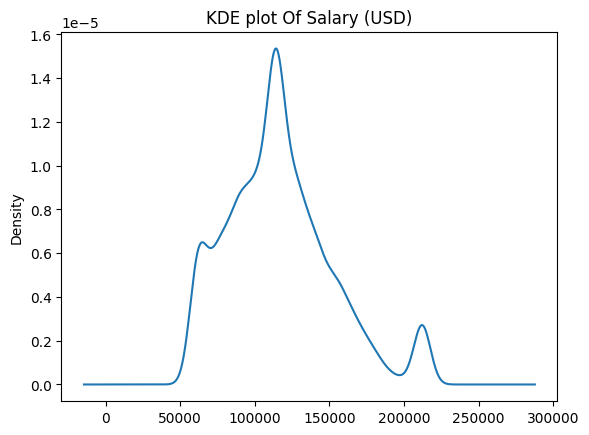

In [ ]:
df['Salary (USD)'].plot(kind='kde')
plt.title("KDE plot Of Salary (USD)")
plt.show()

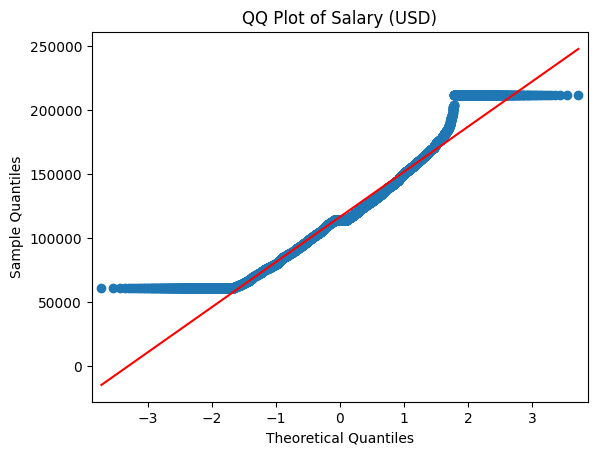

In [ ]:
# QQ plot
import statsmodels.api as sm

sm.qqplot(df['Salary (USD)'], line='s')
plt.title('QQ Plot of Salary (USD)')
plt.show()

Transformations

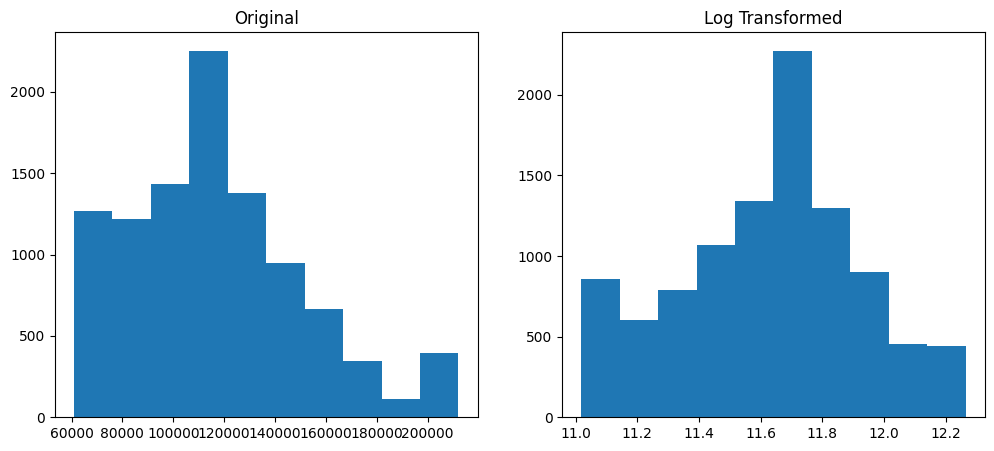

In [ ]:
# log transformation
df['salary_after_log'] = np.log(df['Salary (USD)'])

# plot
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].hist(df['Salary (USD)'])
ax[0].set_title("Original")

ax[1].hist(df['salary_after_log'])
ax[1].set_title("Log Transformed")

# df['salary_after_log'].plot(kind='kde')
# plt.title("KDE plot Of Salary (USD)")
plt.show()

Lambda : 0.14445030661404384


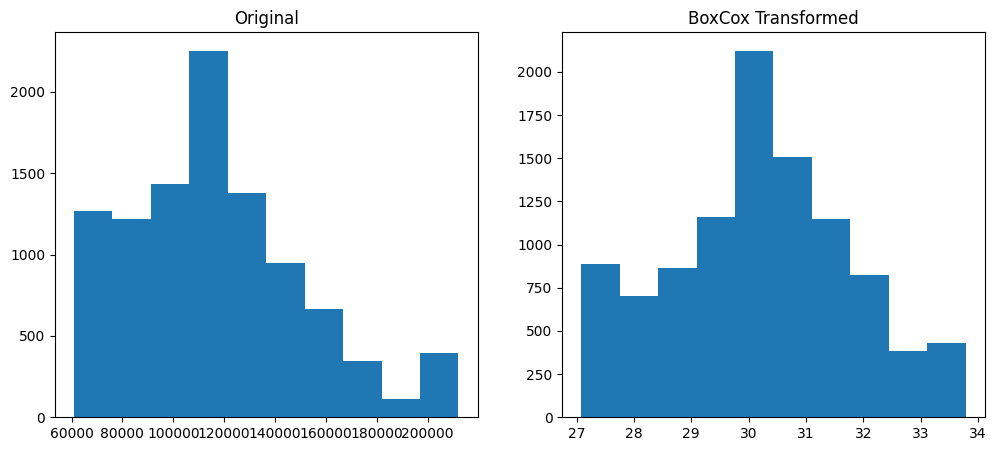

In [ ]:
# boxcox transformation
from scipy.stats import boxcox

df['salary_after_boxcox'] , lam = boxcox(df['Salary (USD)'])
print("Lambda :", lam)

# plot
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].hist(df['Salary (USD)'])
ax[0].set_title("Original")

ax[1].hist(df['salary_after_boxcox'])
ax[1].set_title("BoxCox Transformed")

# df['salary_after_boxcox'].plot(kind='kde')
# plt.title("KDE plot Of Salary (USD)")
plt.show()

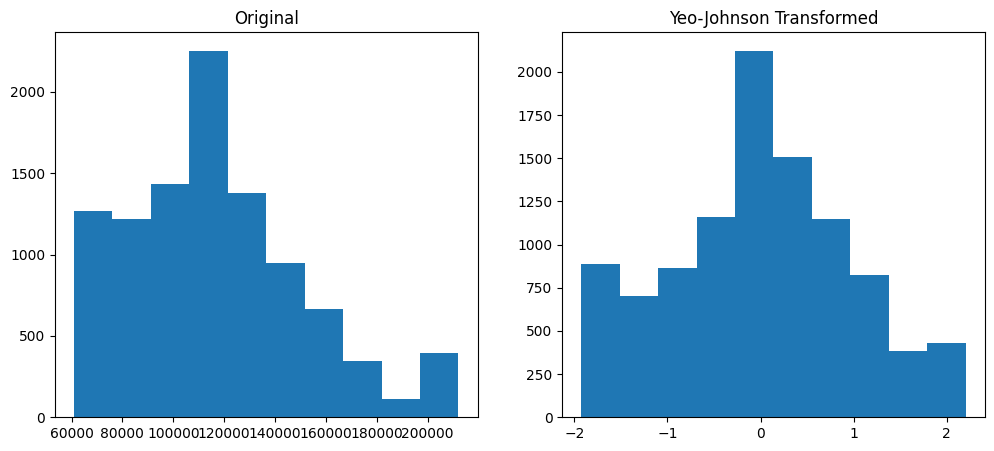

In [ ]:
# yeo-johnson
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['salary_after_yeo'] = pt.fit_transform(df[['Salary (USD)']])

# plot
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].hist(df['Salary (USD)'])
ax[0].set_title("Original")

ax[1].hist(df['salary_after_yeo'])
ax[1].set_title("Yeo-Johnson Transformed")

# df['salary_after_yeo'].plot(kind='kde')
# plt.title("KDE plot Of Salary (USD)")
plt.show()


In [ ]:
from scipy.stats import shapiro

stat1, p_value1 = shapiro(df['salary_after_yeo'])
stat2, p_value2 = shapiro(df['salary_after_log'])
stat3, p_value3 = shapiro(df['salary_after_boxcox'])

# yeo-johnson
print("Yeo-Johnson Shapiro Statistic:", stat1)
print("Yeo-Johnson P-Value :", p_value1)

# log
print("Log Shapiro Statistic:", stat2)
print("Log P-Value :", p_value2)

# boxcox
print("Boxcox Shapiro Statistic:", stat3)
print("Boxcox P-Value :", p_value3)

# interpretation
alpha = 0.05
if p_value3 < alpha :
  print("Data is not normally distributed (Reject H0)")
else:
  print("Data is normally distributed (Fails to Reject H0)")

Yeo-Johnson Shapiro Statistic: 0.9814808906476359
Yeo-Johnson P-Value : 4.2539613265932e-34
Log Shapiro Statistic: 0.9801839014944
Log P-Value : 4.587358540953121e-35
Boxcox Shapiro Statistic: 0.9814808889891874
Boxcox P-Value : 4.2539488845092145e-34
Data is not normally distributed (Reject H0)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10025.
  res = hypotest_fun_out(*samples, **kwds)


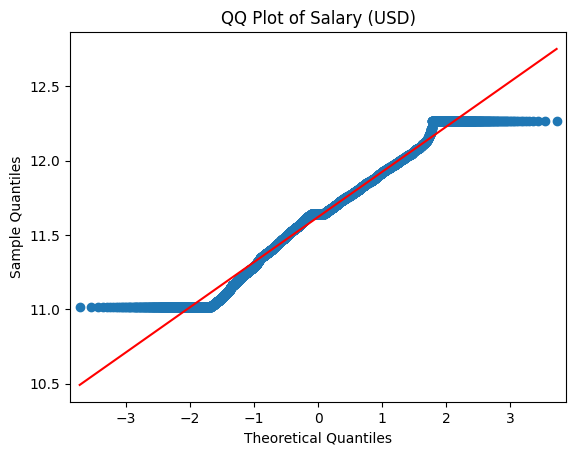

In [ ]:
# QQ plot
import statsmodels.api as sm

sm.qqplot(df['salary_after_log'], line='s')
plt.title('QQ Plot of Salary (USD)')
plt.show()

Meannwhiteneya test

In [ ]:
from scipy.stats import mannwhitneyu

# Define groups for comparison
a = df[df['Skills - Python'] == 0]['Salary (USD)']
b = df[df['Skills - Python'] == 1]['Salary (USD)']

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(a, b)

print("Statistic:", stat)
print("P-Value :", p_value)

# Interpretation
alpha = 0.05
if p_value < alpha:
  print("Reject Null hypothesis: There is a significant difference in salary between python_skilled and non-python_skilled")
else:
  print("Fail to reject Null hypothesis: There is no significant difference in salary between python_skilled and non-python_skilled")

Statistic: 12206649.5
P-Value : 0.7444228840465112
Fail to reject Null hypothesis: There is no significant difference in salary between python_skilled and non-python_skilled


In [ ]:
from scipy.stats import mannwhitneyu

# Define groups for comparison
a = df[df['Skills - SQL'] == 0]['Salary (USD)']
b = df[df['Skills - SQL'] == 1]['Salary (USD)']

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(a, b)

print("Statistic:", stat)
print("P-Value :", p_value)

# Interpretation
alpha = 0.05
if p_value < alpha:
  print("Reject Null hypothesis: There is a significant difference in salary between sql_skilled and non-sql_skilled")
else:
  print("Fail to reject Null hypothesis: There is no significant difference in salary between sql_skilled and non-sql_skilled")

Statistic: 12434882.5
P-Value : 0.41765998858415443
Fail to reject Null hypothesis: There is no significant difference in salary between sql_skilled and non-sql_skilled


In [ ]:
from scipy.stats import mannwhitneyu

# Define groups for comparison
a = df[df['Skills - ML'] == 0]['Salary (USD)']
b = df[df['Skills - ML'] == 1]['Salary (USD)']

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(a, b)

print("Statistic:", stat)
print("P-Value :", p_value)

# Interpretation
alpha = 0.05
if p_value < alpha:
  print("Reject Null hypothesis: There is a significant difference in salary between ml_skilled and non-ml_skilled")
else:
  print("Fail to reject Null hypothesis: There is no significant difference in salary between ml_skilled and non-ml_skilled")

Statistic: 9897940.5
P-Value : 8.902154355911891e-63
Reject Null hypothesis: There is a significant difference in salary between ml_skilled and non-ml_skilled


In [ ]:
from scipy.stats import mannwhitneyu

# Define groups for comparison
a = df[df['Skills-DeepLearning'] == 0]['Salary (USD)']
b = df[df['Skills-DeepLearning'] == 1]['Salary (USD)']

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(a, b)

print("Statistic:", stat)
print("P-Value :", p_value)

# Interpretation
alpha = 0.05
if p_value < alpha:
  print("Reject Null hypothesis: There is a significant difference in salary between deep-learning_skilled and non-deep-learning_skilled")
else:
  print("Fail to reject Null hypothesis: There is no significant difference in salary between deep-learning_skilled and non-deep-learning_skilled")

Statistic: 9819376.0
P-Value : 2.0232379904133182e-67
Reject Null hypothesis: There is a significant difference in salary between deep-learning_skilled and non-deep-learning_skilled


In [ ]:
from scipy.stats import mannwhitneyu

# Define groups for comparison
a = df[df['skills_Cloud'] == 0]['Salary (USD)']
b = df[df['skills_Cloud'] == 1]['Salary (USD)']

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(a, b)

print("Statistic:", stat)
print("P-Value :", p_value)

# Interpretation
alpha = 0.05
if p_value < alpha:
  print("Reject Null hypothesis: There is a significant difference in salary between cloud_skilled and non-cloud_skilled")
else:
  print("Fail to reject Null hypothesis: There is no significant difference in salary between cloud_skilled and non-cloud_skilled")

Statistic: 11003592.0
P-Value : 1.622448484400534e-19
Reject Null hypothesis: There is a significant difference in salary between cloud_skilled and non-cloud_skilled


In [ ]:
# so from this test 3 skills are important or significatly effecting salary ( Cloud, ML, Deep-Learning)

Levene test

In [ ]:
from scipy.stats import levene

#groups
a = df[df['Skills - Python'] == 1]['Salary (USD)']
b = df[df['Skills - Python'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = levene(a,b)

print('Levene Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Variances are not equal (Reject H0)")
else:
  print("Variances are equal (Fail to Reject H0)")

Levene Statistic : 0.06954666394071869
P-Value : 0.7920034049693223
Variances are equal (Fail to Reject H0)


In [ ]:
from scipy.stats import levene

#groups
a = df[df['Skills - SQL'] == 1]['Salary (USD)']
b = df[df['Skills - SQL'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = levene(a,b)

print('Levene Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Variances are not equal (Reject H0)")
else:
  print("Variances are equal (Fail to Reject H0)")

Levene Statistic : 1.0060642871885972
P-Value : 0.3158717776811179
Variances are equal (Fail to Reject H0)


In [ ]:
from scipy.stats import levene

#groups
a = df[df['Skills - ML'] == 1]['Salary (USD)']
b = df[df['Skills - ML'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = levene(a,b)

print('Levene Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Variances are not equal (Reject H0)")
else:
  print("Variances are equal (Fail to Reject H0)")

Levene Statistic : 2.20342114948016
P-Value : 0.137736264636333
Variances are equal (Fail to Reject H0)


In [ ]:
from scipy.stats import levene

#groups
a = df[df['Skills-DeepLearning'] == 1]['Salary (USD)']
b = df[df['Skills-DeepLearning'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = levene(a,b)

print('Levene Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Variances are not equal (Reject H0)")
else:
  print("Variances are equal (Fail to Reject H0)")

Levene Statistic : 9.558711407265111
P-Value : 0.0019954898211251375
Variances are not equal (Reject H0)


In [ ]:
from scipy.stats import levene

#groups
a = df[df['skills_Cloud'] == 1]['Salary (USD)']
b = df[df['skills_Cloud'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = levene(a,b)

print('Levene Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Variances are not equal (Reject H0)")
else:
  print("Variances are equal (Fail to Reject H0)")

Levene Statistic : 3.609840517105041
P-Value : 0.05746729950717372
Variances are equal (Fail to Reject H0)


Hypthesis Testing

In [ ]:
# numerical vs binary
# null hypothesis : salay of python_skilled = non-python_skilled

from scipy.stats import ttest_ind

#groups
a = df[df['Skills - Python'] == 1]['Salary (USD)']
b = df[df['Skills - Python'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = ttest_ind(a,b)

print('T-Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Reject Null hypothesis : Python_skill affects Salary.")
else:
  print("fail to reject Null hypothesis : Python_skill doesn't affects Salary.")

T-Statistic : 0.03201290585405775
P-Value : 0.9744623962079679
fail to reject Null hypothesis : Python_skill doesn't affects Salary.


In [ ]:
# null hypothesis : salay of SQL_skilled = non-SQL_skilled

from scipy.stats import ttest_ind

#groups
a = df[df['Skills - SQL'] == 1]['Salary (USD)']
b = df[df['Skills - SQL'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = ttest_ind(a,b)

print('T-Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Reject Null hypothesis : SQL_skill affects Salary.")
else:
  print("fail to reject Null hypothesis : SQL_skill doesn't affects Salary.")

T-Statistic : -0.9706998653150588
P-Value : 0.33172118262937367
fail to reject Null hypothesis : SQL_skill doesn't affects Salary.


In [ ]:
# null hypothesis : salay of ML_skilled = non-ML_skilled

from scipy.stats import ttest_ind

#groups
a = df[df['Skills - ML'] == 1]['Salary (USD)']
b = df[df['Skills - ML'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = ttest_ind(a,b)

print('T-Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Reject Null hypothesis : ML_skill affects Salary.")
else:
  print("fail to reject Null hypothesis : ML_skill doesn't affects Salary.")

T-Statistic : 15.573344751558778
P-Value : 4.737203364074925e-54
Reject Null hypothesis : ML_skill affects Salary.


In [ ]:
# null hypothesis : salay of DeepLearning_skilled = non-DeepLearningskilled

from scipy.stats import ttest_ind

#groups
a = df[df['Skills-DeepLearning'] == 1]['Salary (USD)']
b = df[df['Skills-DeepLearning'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = ttest_ind(a,b)

print('T-Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Reject Null hypothesis : DeepLearning_skill affects Salary.")
else:
  print("fail to reject Null hypothesis : DeepLearning_skill doesn't affects Salary.")

T-Statistic : 16.36698847977974
P-Value : 1.9354881733150994e-59
Reject Null hypothesis : DeepLearning_skill affects Salary.


In [ ]:
# null hypothesis : salay of cloud_skilled = non-cloud_skilled

from scipy.stats import ttest_ind

#groups
a = df[df['skills_Cloud'] == 1]['Salary (USD)']
b = df[df['skills_Cloud'] == 0]['Salary (USD)']

#t-test
t_stat, p_value = ttest_ind(a,b)

print('T-Statistic :', t_stat)
print('P-Value :', p_value)

# interpretation
# alpha = 0.05
if p_value < 0.05 :
  print("Reject Null hypothesis : Cloud_skill affects Salary.")
else:
  print("fail to reject Null hypothesis : Cloud_skill doesn't affects Salary.")

T-Statistic : 7.9836927534699464
P-Value : 1.5759321210769164e-15
Reject Null hypothesis : Cloud_skill affects Salary.


Chi-Square Test

In [ ]:
# categorical vs categorical

from scipy.stats import chi2_contingency

#contingency table
table = pd.crosstab(df['Hiring Urgency'], df['Skills - ML'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between hiring urgency and ML skill")
else:
  print("no Significant association")

Chi-Square : 20.016751118569292
P-Value : 4.502126792516522e-05
DOF : 2
Expected: 
 [[1699.61895262 2281.38104738]
 [1563.00049875 2097.99950125]
 [1017.38054863 1365.61945137]]
Significant association between hiring urgency and ML skill


In [ ]:
from scipy.stats import chi2_contingency

#contingency table
table = pd.crosstab(df['Hiring Urgency'], df['Skills-DeepLearning'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between hiring urgency and Deep-LearningL skill")
else:
  print("no Significant association")

Chi-Square : 12.881998219199366
P-Value : 0.001594812491889891
DOF : 2
Expected: 
 [[2274.63022444 1706.36977556]
 [2091.7913217  1569.2086783 ]
 [1361.57845387 1021.42154613]]
Significant association between hiring urgency and Deep-LearningL skill


In [ ]:
#contingency table
table = pd.crosstab(df['posting_Year'], df['Skills - ML'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Posting year and ML skill")
else:
  print("no Significant association")

Chi-Square : 8.029355039119158
P-Value : 0.2359605621425954
DOF : 6
Expected: 
 [[598.559601   803.440399  ]
 [613.92917706 824.07082294]
 [615.20997506 825.79002494]
 [580.20149626 778.79850374]
 [646.37605985 867.62394015]
 [611.79451372 821.20548628]
 [613.92917706 824.07082294]]
no Significant association


In [ ]:
#contingency table
table = pd.crosstab(df['posting_Year'], df['skills_Cloud'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Posting_Year and CloudL skill")
else:
  print("no Significant association")

Chi-Square : 12.592053780532467
P-Value : 0.04999147559884154
DOF : 6
Expected: 
 [[599.39870324 802.60129676]
 [614.78982544 823.21017456]
 [616.07241895 824.92758105]
 [581.01486284 777.98513716]
 [647.28219451 866.71780549]
 [612.65216958 820.34783042]
 [614.78982544 823.21017456]]
Significant association between Posting_Year and CloudL skill


In [ ]:
#contingency table
table = pd.crosstab(df['posting_Year'], df['Education  Level'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Posting_Year and Education  Level")
else:
  print("no Significant association")

Chi-Square : 16.60125029593049
P-Value : 0.5506615487424826
DOF : 18
Expected: 
 [[427.24289277 441.50763092 429.62034913 103.62912718]
 [438.21346633 452.84448878 440.65197007 106.29007481]
 [439.1276808  453.78922693 441.57127182 106.51182045]
 [414.13915212 427.96638404 416.44369077 100.45077307]
 [461.37356608 476.77785536 463.94094763 111.90763092]
 [436.68977556 451.26992519 439.1198005  105.92049875]
 [438.21346633 452.84448878 440.65197007 106.29007481]]
no Significant association


In [ ]:
#contingency table
table = pd.crosstab(df['Company Size'], df['Remote Type'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Company Size and Remote Type")
else:
  print("No Significant association between Company Size and Remote Type")

Chi-Square : 2.0297712409334725
P-Value : 0.9909880079707927
DOF : 9
Expected: 
 [[1434.92149626 1435.38753117 1473.60239401  328.08857855]
 [ 703.02553616  703.25386534  721.97685786  160.74374065]
 [ 732.20309227  732.44089776  751.94094763  167.41506234]
 [ 208.84987531  208.91770574  214.4798005    47.75261845]]
No Significant association between Company Size and Remote Type


In [ ]:
#contingency table
table = pd.crosstab(df['Company Size'], df['Education  Level'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Company Size and Education  Level")
else:
  print("No Significant association between Company Size and Education  Level")

Chi-Square : 23.69652550814424
P-Value : 0.004807782079736513
DOF : 9
Expected: 
 [[1423.73665835 1471.27221945 1431.65925187  345.33187032]
 [ 697.54563591  720.83521197  701.42723192  169.1919202 ]
 [ 726.4957606   750.7519202   730.53845387  176.21386534]
 [ 207.22194514  214.14064838  208.37506234   50.26234414]]
Significant association between Company Size and Education  Level


In [ ]:
#contingency table
table = pd.crosstab(df['Company Size'], df['Hiring Urgency'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Company Size and Hiring Urgency")
else:
  print("No Significant association between Company Size and Hiring Urgency")

Chi-Square : 8.06930524119242
P-Value : 0.2330696853522158
DOF : 6
Expected: 
 [[1855.28498753 1706.15381546 1110.56119701]
 [ 908.97845387  835.91311721  544.10842893]
 [ 946.7036409   870.60588529  566.69047382]
 [ 270.03291771  248.32718204  161.63990025]]
No Significant association between Company Size and Hiring Urgency


In [ ]:
#contingency table
table = pd.crosstab(df['company_Industry'], df['Posting Month'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Company Industry and Posting Month")
else:
  print("No Significant association between Company Industry and Posting Month")

Chi-Square : 76.5620667470594
P-Value : 0.17573907690829865
DOF : 66
Expected: 
 [[264.31890274 118.16977556 114.41835411 126.61047382 114.73097257
  121.2959601  113.63680798 122.54643392 115.19990025 118.32608479
  115.5125187  122.23381546]
 [258.24648379 115.45496259 111.78972569 123.70174564 112.09516209
  118.50932668 111.02613466 119.73107232 112.55331671 115.6076808
  112.85875312 119.42563591]
 [269.04189526 120.28129676 116.46284289 128.87281796 116.78104738
  123.46334165 115.66733167 124.7361596  117.25835411 120.440399
  117.5765586  124.41795511]
 [261.62004988 116.96319202 113.25007481 125.31770574 113.55950125
  120.05745636 112.47650873 121.29516209 114.0236409  117.11790524
  114.33306733 120.98573566]
 [271.74074813 121.4878803  117.63112219 130.16558603 117.9525187
  124.70184539 116.82763092 125.98743142 118.43461347 121.64857855
  118.75600998 125.66603491]
 [252.00538653 112.66473815 109.0880798  120.71221945 109.38613466
  115.64528678 108.34294264 116.83750623 

In [ ]:
#contingency table
table = pd.crosstab(df['company_Industry'], df['posting_Year'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Company Industry and Posting Year")
else:
  print("No Significant association between Company Industry and Posting Year")

Chi-Square : 47.88088769572526
P-Value : 0.08898061435500167
DOF : 36
Expected: 
 [[219.14553616 224.77266833 225.24159601 212.4242394  236.65216958
  223.99112219 224.77266833]
 [214.11092269 219.60877805 220.06693267 207.5440399  231.2153616
  218.84518703 219.60877805]
 [223.06134663 228.78902743 229.26633416 216.21995012 240.880798
  227.99351621 228.78902743]
 [216.90793017 222.47760599 222.94174564 210.25526185 234.23581047
  221.7040399  222.47760599]
 [225.29895262 231.08408978 231.56618454 218.38892768 243.29715711
  230.2805985  231.08408978]
 [208.93645885 214.30144638 214.74852868 202.5282793  225.62753117
  213.55630923 214.30144638]
 [ 94.53885287  96.96638404  97.1686783   91.63930175 102.09117207
   96.62922693  96.96638404]]
No Significant association between Company Industry and Posting Month


In [ ]:
#contingency table
table = pd.crosstab(df['skills_Cloud'], df['posting_Year'])

#test
chi2, p_value, dof, expected = chi2_contingency(table)

#output
print("Chi-Square :", chi2)
print("P-Value :", p_value)
print("DOF :", dof)
print("Expected: \n", expected)

#interpretation
alpha = 0.05
if p_value < alpha:
  print("Significant association between Cloud Skills and Posting Year")
else:
  print("No Significant association between Cloud Skills and Posting Year")

Chi-Square : 12.592053780532467
P-Value : 0.04999147559884154
DOF : 6
Expected: 
 [[599.39870324 614.78982544 616.07241895 581.01486284 647.28219451
  612.65216958 614.78982544]
 [802.60129676 823.21017456 824.92758105 777.98513716 866.71780549
  820.34783042 823.21017456]]
Significant association between Cloud Skills and Posting Year


multicollinearity analysis

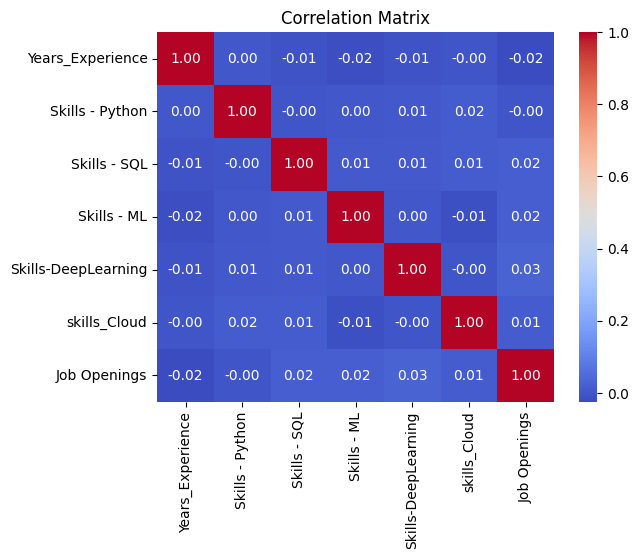

In [ ]:
cols = [
    "Years_Experience",
    "Skills - Python",
    "Skills - SQL",
    "Skills - ML",
    "Skills-DeepLearning",
    "skills_Cloud",
    "Job Openings"
]

corr_matrix = df[cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()